In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats.mstats import winsorize
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, ConfusionMatrixDisplay

In [2]:
df = pd.read_csv('Датасет №1_Airline Passenger Satisfaction_mod.csv')
print(df.info())
print(df.describe())
print(df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103910 entries, 0 to 103909
Data columns (total 25 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   id                                 103910 non-null  int64  
 1   Gender                             103858 non-null  object 
 2   Customer Type                      103910 non-null  object 
 3   Age                                103910 non-null  int64  
 4   Type of Travel                     103910 non-null  object 
 5   Class                              103910 non-null  object 
 6   Flight Distance                    103910 non-null  int64  
 7   Inflight wifi service              103910 non-null  int64  
 8   Departure/Arrival time convenient  103910 non-null  int64  
 9   Ease of Online booking             103792 non-null  float64
 10  Gate location                      103910 non-null  int64  
 11  Food and drink                     1039

In [3]:
df.drop_duplicates(keep=False, inplace=True)
df.shape


(103898, 25)

In [4]:
df.groupby(['Gender']).agg({'Age': ['mean', 'max']})

Age    
             mean max
Gender               
Female  39.233477  97
Male    39.510704  98

In [5]:
df.groupby(['Class']).agg({'Age': ['mean', 'max']})

Age    
               mean max
Class                  
Busines   24.000000  26
Business  41.567210  97
Eco       37.154189  98
Eco Plus  38.639434  85
Econom    43.050000  68

In [6]:
df.groupby(['Gender','Class']).agg({'Age': ['mean', 'max']})

Age    
                      mean max
Gender Class                  
Female Busines   26.000000  26
       Business  41.508591  97
       Eco       37.000797  85
       Eco Plus  38.357959  85
       Econom    41.000000  65
Male   Busines   22.000000  22
       Business  41.622390  97
       Eco       37.315640  98
       Eco Plus  38.938839  80
       Econom    44.727273  68

In [7]:
df.groupby(['Gender']).agg({ 'Age': ['mean'], 'Flight Distance': ['mean', 'max']})

Age Flight Distance      
             mean            mean   max
Gender                                 
Female  39.233477     1183.828004  4983
Male    39.510704     1195.319276  4983

In [8]:
df['Class'] = df['Class'].replace('Busines', 'Business')
df['Class'] = df['Class'].replace('Eco', 'Econom')
df['Customer Type'] = df['Customer Type'].replace('disloyal Customer', 'Disloyal Customer')

In [9]:
df.dropna(subset=['Gender', 'Ease of Online booking'], inplace=True)
df['Leg room service'] = df['Leg room service'].fillna(df['Leg room service'].mode()[0])
df['Baggage handling'] = df['Baggage handling'].fillna(df['Baggage handling'].mode()[0])
df['Arrival Delay in Minutes'] = df['Arrival Delay in Minutes'].fillna(df['Arrival Delay in Minutes'].median())

In [10]:
df_wins = df.copy()

limits = (0.01, 0.01)

df_wins['Flight Distance'] = winsorize(df['Flight Distance'], limits=limits)
df_wins['Departure Delay in Minutes'] = winsorize(df['Departure Delay in Minutes'], limits=limits)
df_wins['Arrival Delay in Minutes'] = winsorize(df['Arrival Delay in Minutes'], limits=limits)

df_wins.head

<bound method NDFrame.head of             id  Gender      Customer Type  Age   Type of Travel     Class  \
0        70172    Male     Loyal Customer   13  Personal Travel  Eco Plus   
1         5047    Male  Disloyal Customer   25  Business travel  Business   
2       110028  Female     Loyal Customer   26  Business travel  Business   
3        24026  Female     Loyal Customer   25  Business travel  Business   
4       119299    Male     Loyal Customer   61  Business travel  Business   
...        ...     ...                ...  ...              ...       ...   
103899   94171  Female  Disloyal Customer   23  Business travel    Econom   
103900   73097    Male     Loyal Customer   49  Business travel  Business   
103901   68825    Male  Disloyal Customer   30  Business travel  Business   
103902   54173  Female  Disloyal Customer   22  Business travel    Econom   
103903   62567    Male     Loyal Customer   27  Business travel  Business   

        Flight Distance  Inflight wifi servic

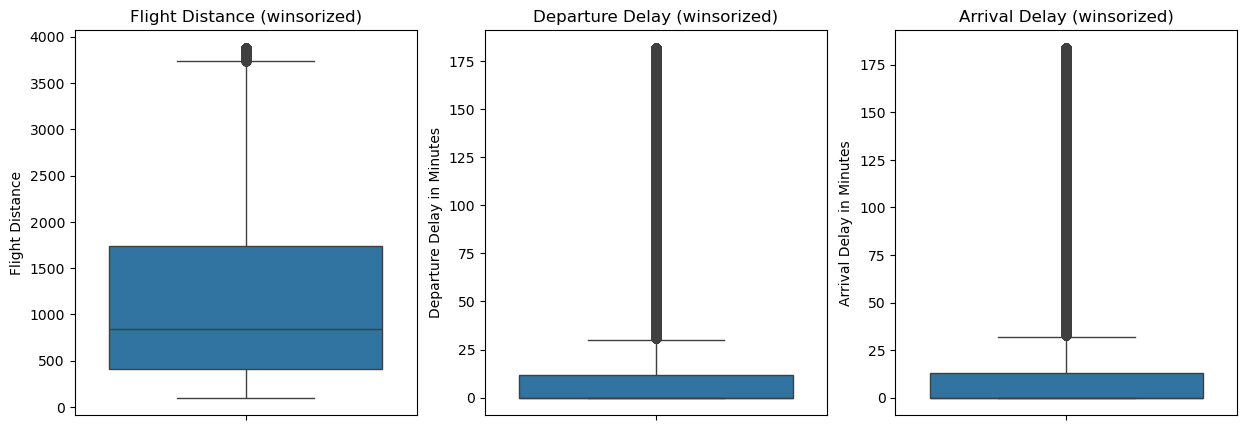

In [11]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.boxplot(y=df_wins['Flight Distance'])
plt.title('Flight Distance (winsorized)')

plt.subplot(1, 3, 2)
sns.boxplot(y=df_wins['Departure Delay in Minutes'])
plt.title('Departure Delay (winsorized)')

plt.subplot(1, 3, 3)
sns.boxplot(y=df_wins['Arrival Delay in Minutes'])
plt.title('Arrival Delay (winsorized)')

plt.show()

In [12]:
print("Текущее распределение:")
print(df['satisfaction'].value_counts())

Текущее распределение:
satisfaction
neutral or dissatisfied    58777
satisfied                  44951
Name: count, dtype: int64


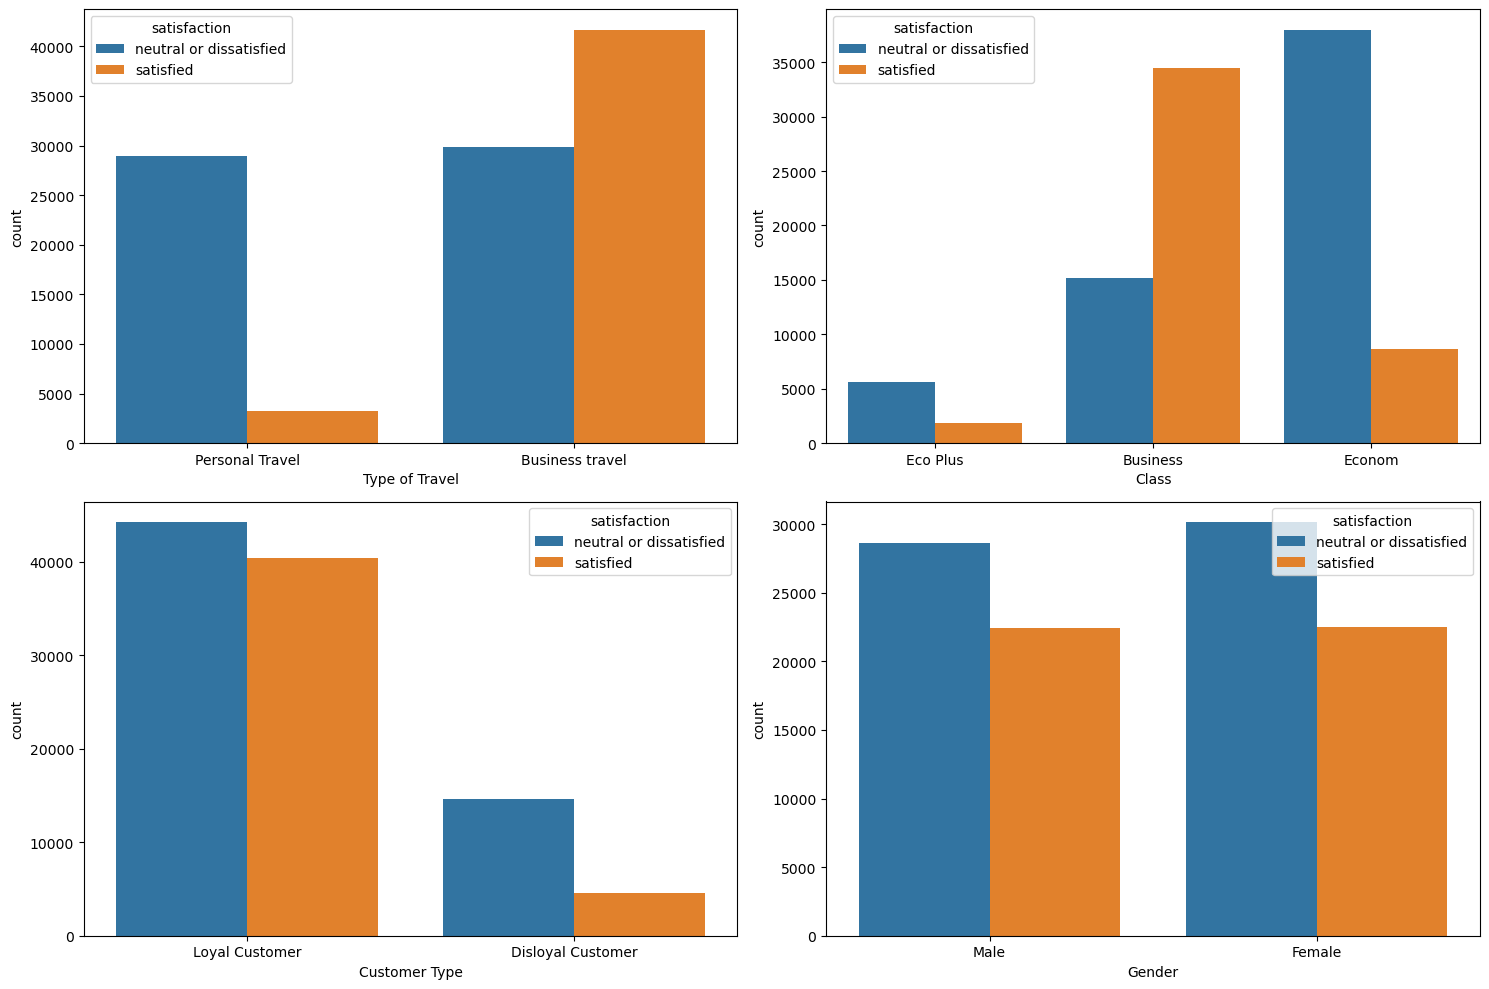

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

sns.countplot(data=df, x='Type of Travel', hue='satisfaction', ax=axes[0,0])
sns.countplot(data=df, x='Class', hue='satisfaction', ax=axes[0,1])
sns.countplot(data=df, x='Customer Type', hue='satisfaction', ax=axes[1,0])
sns.countplot(data=df, x='Gender', hue='satisfaction', ax=axes[1,1])
plt.tight_layout()
plt.show()

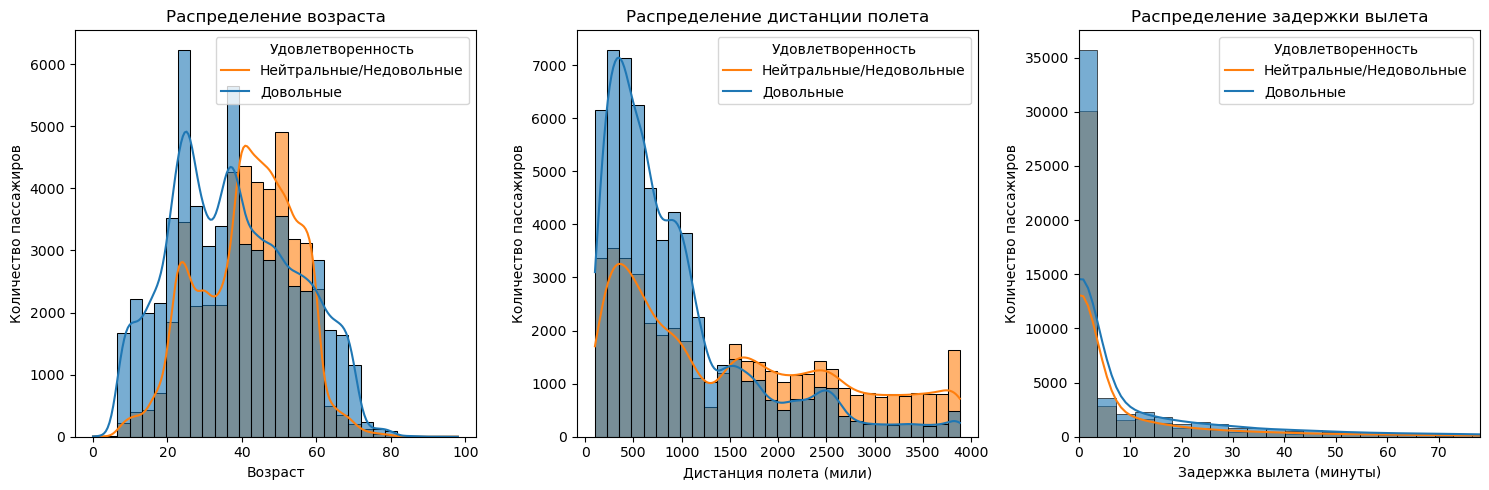

In [14]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.histplot(data=df, x='Age', hue='satisfaction',
             kde=True, alpha=0.6, bins=30, common_norm=False)
plt.title('Распределение возраста')
plt.xlabel('Возраст')
plt.ylabel('Количество пассажиров')
plt.legend(title='Удовлетворенность',
           labels=['Нейтральные/Недовольные', 'Довольные'])

plt.subplot(1, 3, 2)
sns.histplot(data=df, x='Flight Distance', hue='satisfaction',
             kde=True, alpha=0.6, bins=30, common_norm=False)
plt.title('Распределение дистанции полета')
plt.xlabel('Дистанция полета (мили)')
plt.ylabel('Количество пассажиров')
plt.legend(title='Удовлетворенность',
           labels=['Нейтральные/Недовольные', 'Довольные'])

plt.subplot(1, 3, 3)
sns.histplot(data=df, x='Departure Delay in Minutes', hue='satisfaction',
             kde=True, alpha=0.6, bins=50, common_norm=False)
plt.title('Распределение задержки вылета')
plt.xlabel('Задержка вылета (минуты)')
plt.ylabel('Количество пассажиров')
plt.xlim(0, df['Departure Delay in Minutes'].quantile(0.95))
plt.legend(title='Удовлетворенность',
           labels=['Нейтральные/Недовольные', 'Довольные'])

plt.tight_layout()
plt.show()

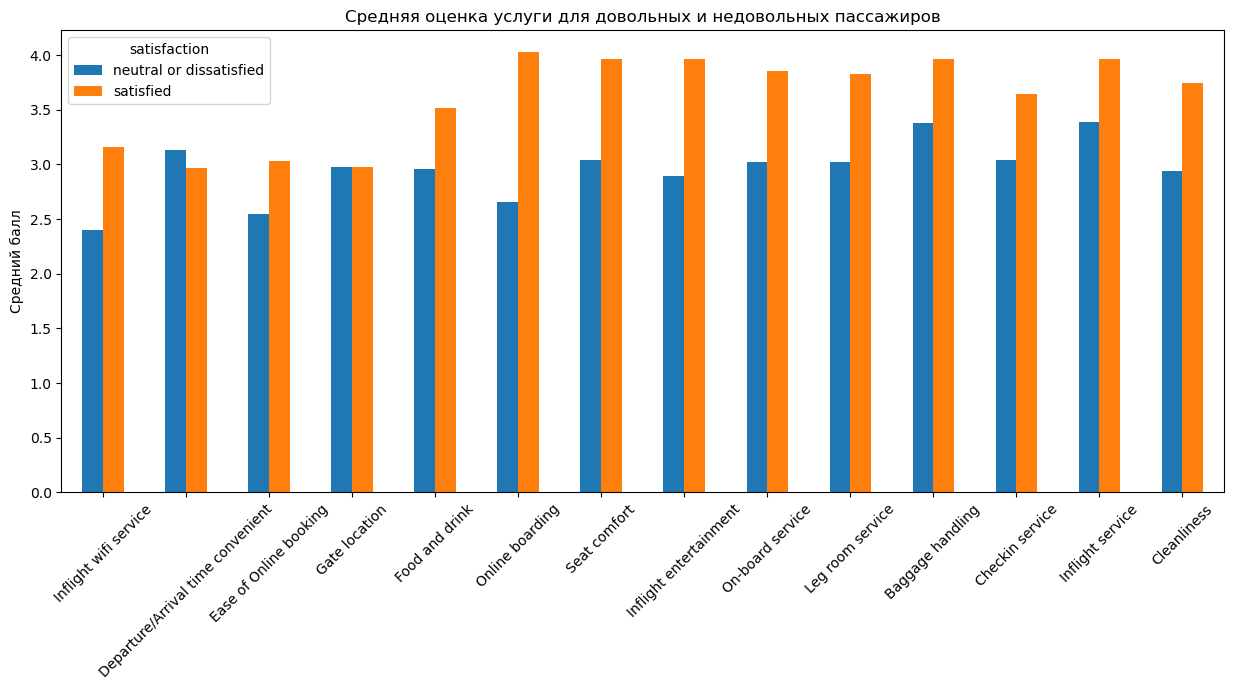

In [15]:
service_columns = ['Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking',
                  'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort',
                  'Inflight entertainment', 'On-board service', 'Leg room service',
                  'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness']

service_by_satisfaction = df.groupby('satisfaction')[service_columns].mean().T

service_by_satisfaction.plot(kind='bar', figsize=(15, 6))
plt.title('Средняя оценка услуги для довольных и недовольных пассажиров')
plt.xticks(rotation=45)
plt.ylabel('Средний балл')
plt.show()

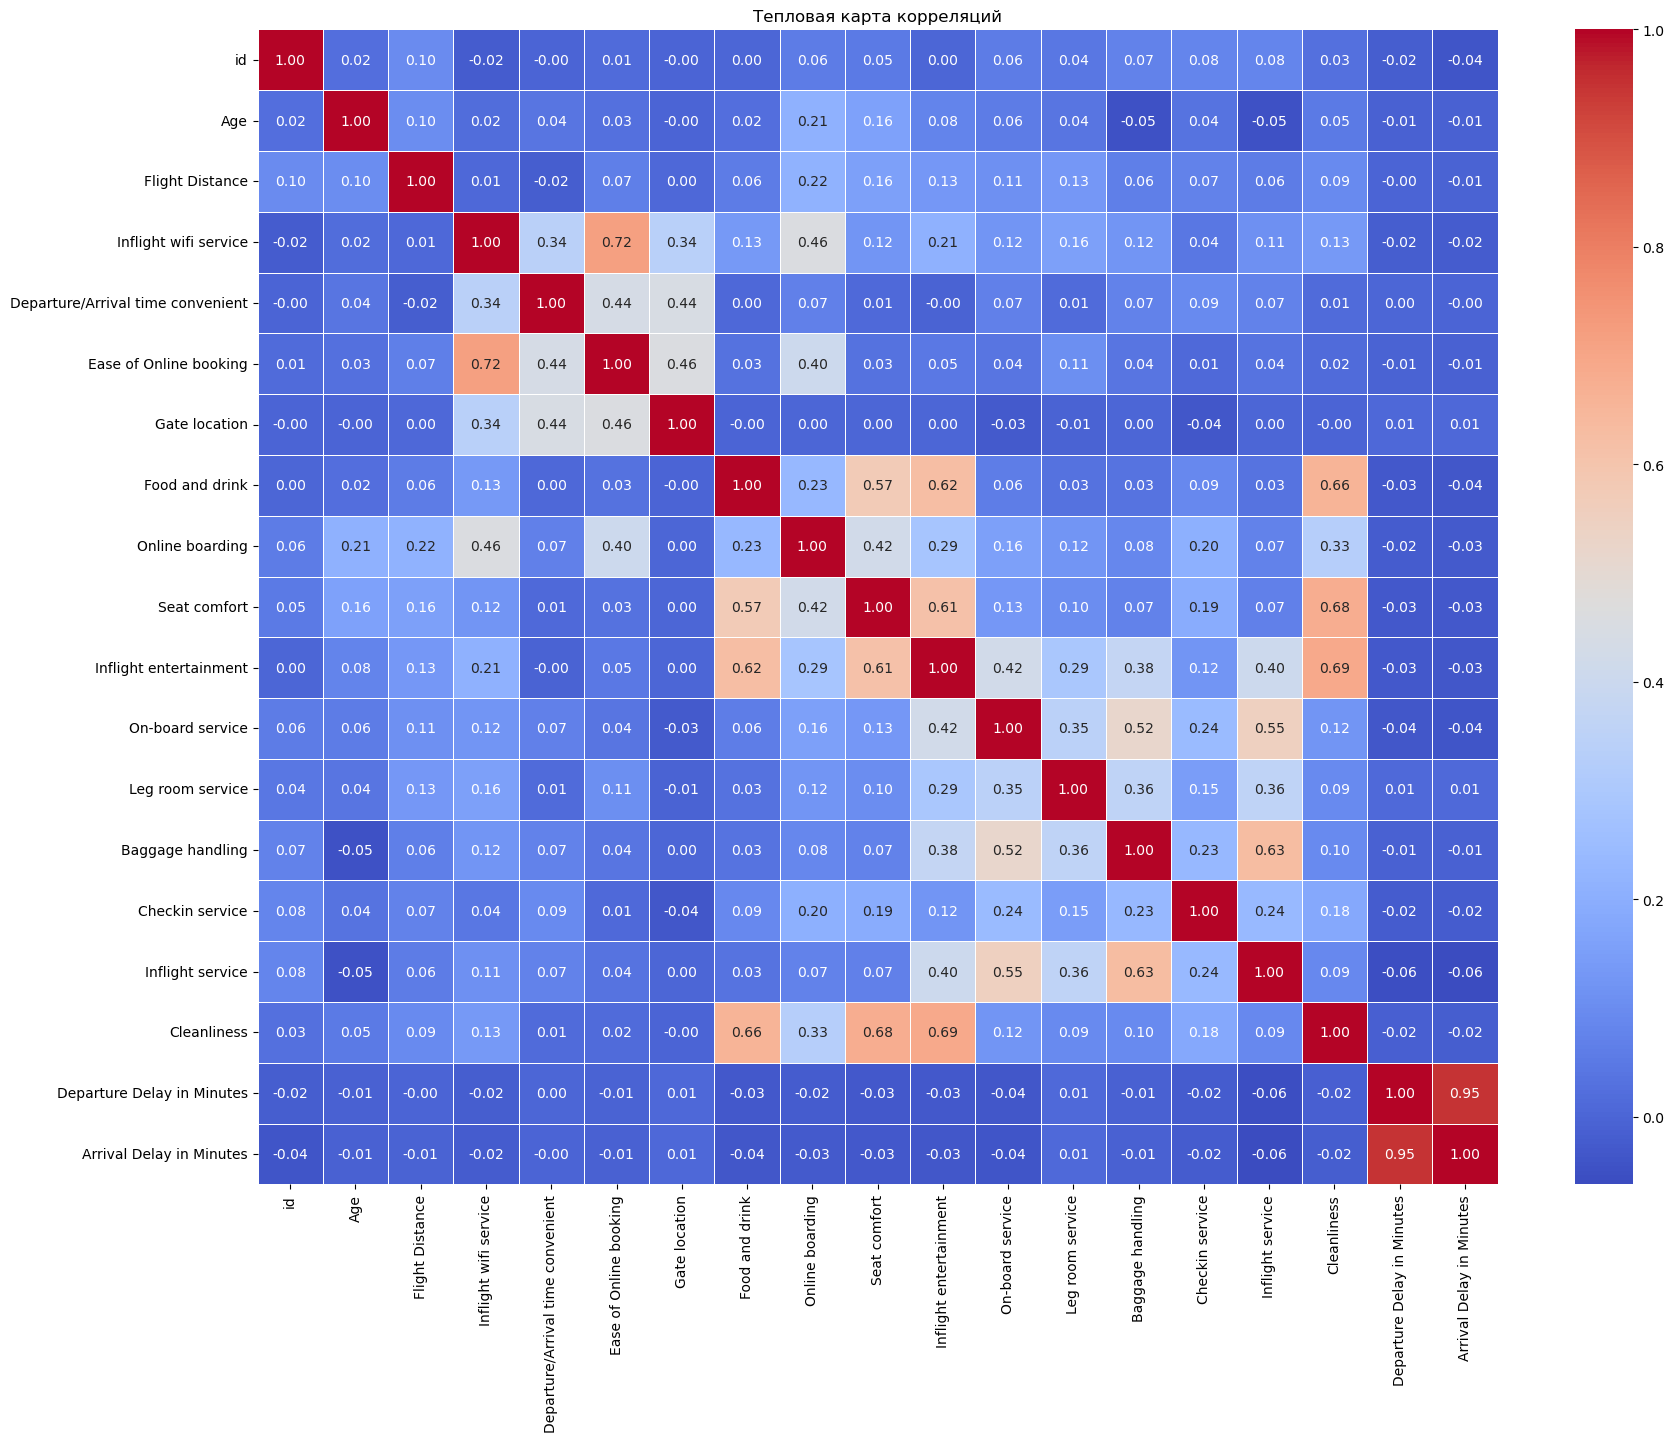

In [16]:
numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(20, 15))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Тепловая карта корреляций')
plt.show()

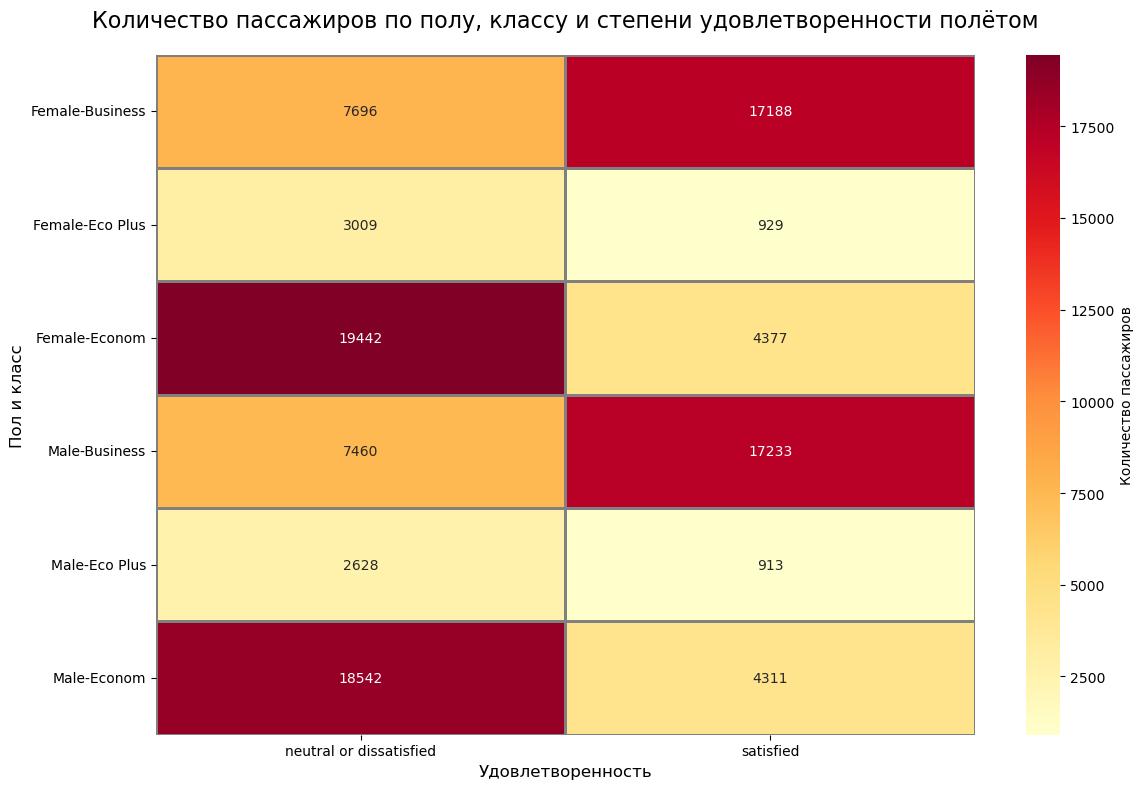

In [17]:
heatmap_data = df.groupby(['Gender', 'Class', 'satisfaction']).size().unstack(level=[0, 1])
heatmap_data = heatmap_data.T

plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=1, linecolor='gray', cbar_kws={'label': 'Количество пассажиров'})
plt.title('Количество пассажиров по полу, классу и степени удовлетворенности полётом', fontsize=16, pad=20)
plt.xlabel('Удовлетворенность', fontsize=12)
plt.ylabel('Пол и класс', fontsize=12)
plt.tight_layout()
plt.show()

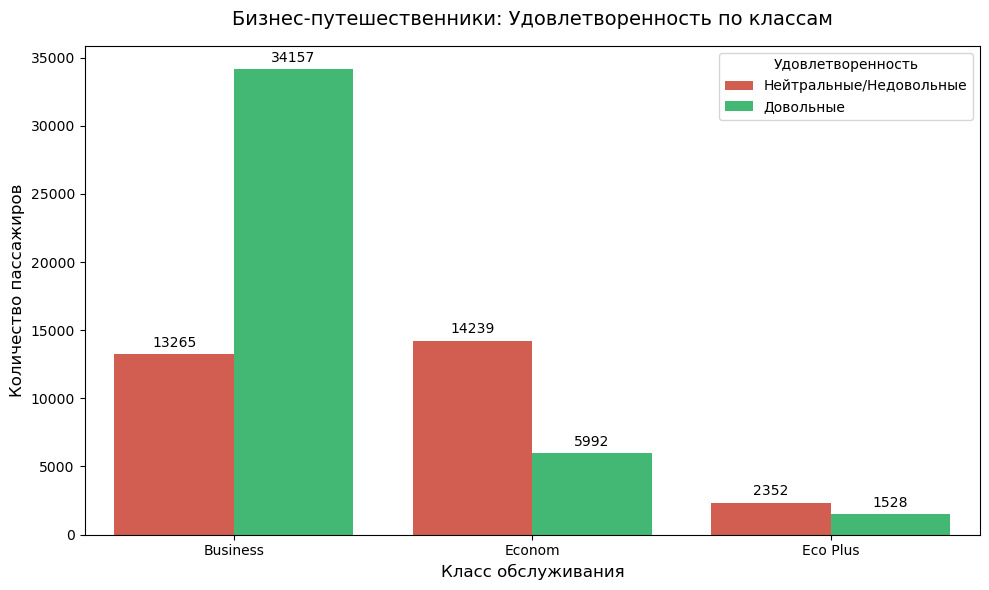

In [18]:
business_df = df[df['Type of Travel'] == 'Business travel']
plt.figure(figsize=(10, 6))

plot_data = business_df[['Class', 'satisfaction']].copy()
plot_data['count'] = 1

ax = sns.countplot(data=plot_data, x='Class', hue='satisfaction',
                   palette={'satisfied': '#2ecc71', 'neutral or dissatisfied': '#e74c3c'})

plt.title('Бизнес-путешественники: Удовлетворенность по классам', fontsize=14, pad=15)
plt.xlabel('Класс обслуживания', fontsize=12)
plt.ylabel('Количество пассажиров', fontsize=12)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, ['Нейтральные/Недовольные', 'Довольные'],
          title='Удовлетворенность')

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3)

plt.tight_layout()
plt.show()

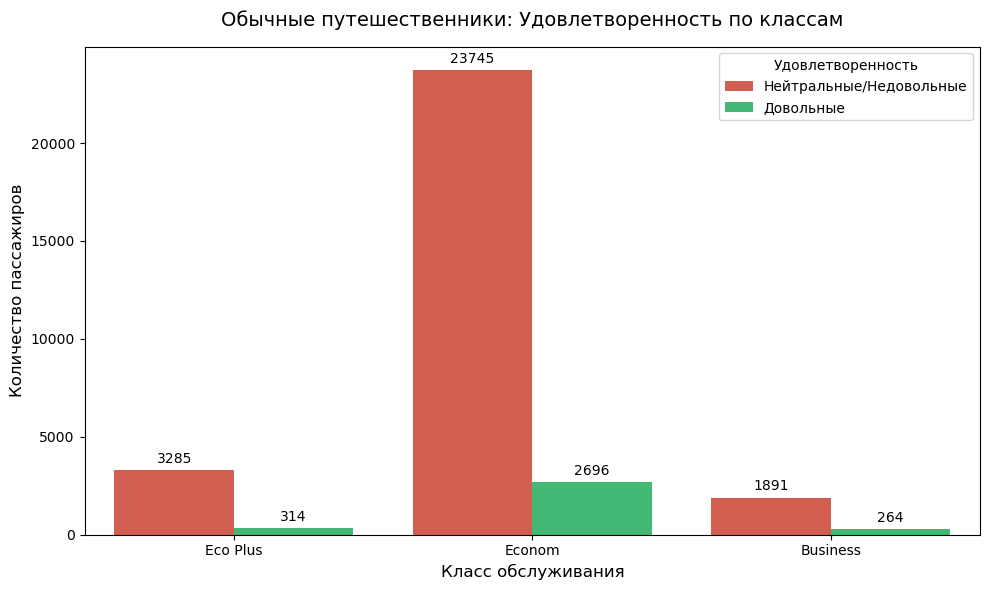

In [19]:
personal_df = df[df['Type of Travel'] == 'Personal Travel']
plt.figure(figsize=(10, 6))

plot_data = personal_df[['Class', 'satisfaction']].copy()
plot_data['count'] = 1

ax = sns.countplot(data=plot_data, x='Class', hue='satisfaction',
                   palette={'satisfied': '#2ecc71', 'neutral or dissatisfied': '#e74c3c'})

plt.title('Обычные путешественники: Удовлетворенность по классам', fontsize=14, pad=15)
plt.xlabel('Класс обслуживания', fontsize=12)
plt.ylabel('Количество пассажиров', fontsize=12)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, ['Нейтральные/Недовольные', 'Довольные'],
          title='Удовлетворенность')

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3)

plt.tight_layout()
plt.show()

In [20]:
bins = [0, 25, 45, 65, 120]
labels = ['Young', 'Adult', 'Middle_Aged', 'Senior']

df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=True, include_lowest=True)

print(df[['Age', 'Age_Group']].head(10))

   Age    Age_Group
0   13        Young
1   25        Young
2   26        Adult
3   25        Young
4   61  Middle_Aged
5   26        Adult
6   47  Middle_Aged
7   52  Middle_Aged
8   41        Adult
9   20        Young


Сводная таблица:
satisfaction  neutral or dissatisfied  satisfied
Age_Group                                       
Young                           16263       6353
Adult                           23501      19789
Middle_Aged                     15743      18071
Senior                           3270        738




<Figure size 1200x600 with 0 Axes>

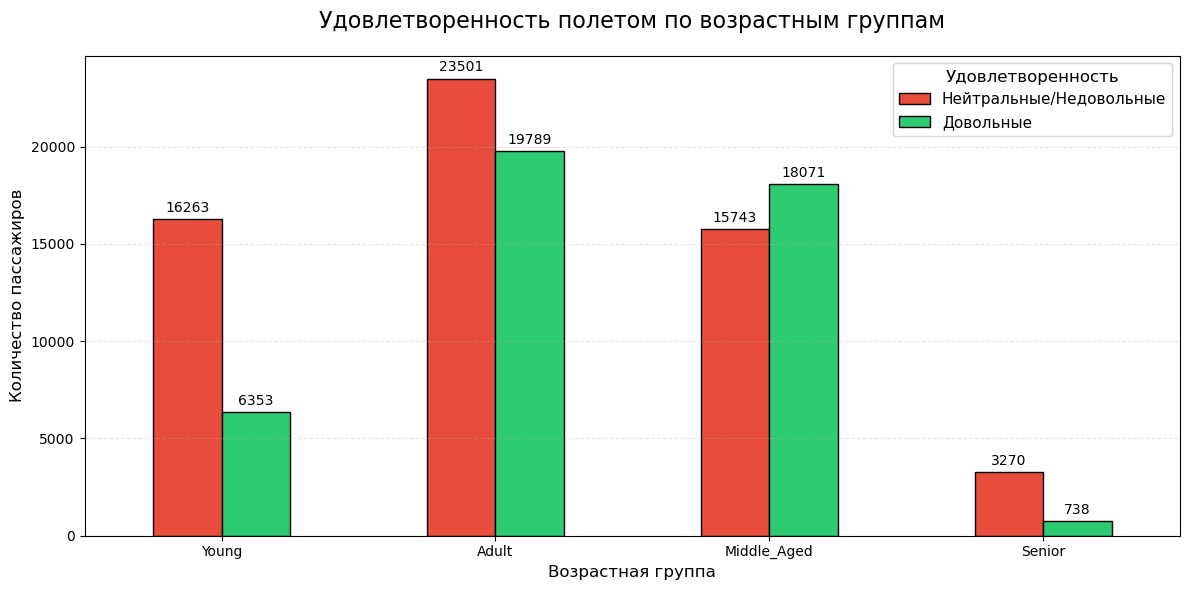

In [21]:
plt.figure(figsize=(12, 6))

age_satisfaction = df.groupby(['Age_Group', 'satisfaction'], observed=True).size().unstack()

print("Сводная таблица:")
print(age_satisfaction)
print("\n")

ax = age_satisfaction.plot(kind='bar', figsize=(12, 6),
                           color=['#e74c3c', '#2ecc71'],
                           edgecolor='black')

plt.title('Удовлетворенность полетом по возрастным группам', fontsize=16, pad=20)
plt.xlabel('Возрастная группа', fontsize=12)
plt.ylabel('Количество пассажиров', fontsize=12)
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3)

plt.legend(['Нейтральные/Недовольные', 'Довольные'],
           title='Удовлетворенность',
           title_fontsize=12,
           fontsize=11)

plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

In [22]:
bins = [0, 250, 750, 1500, 3000, df['Flight Distance'].max() + 1]
labels = ['Ультракороткий', 'Короткий', 'Средний', 'Длинный', 'Межконтинентальный']

df['Flight_Distance_Group'] = pd.cut(df['Flight Distance'],
                                     bins=bins,
                                     labels=labels,
                                     right=False)

print("\nГруппировка по типам перелетов:")
distance_counts = df['Flight_Distance_Group'].value_counts().sort_index()

for group, count in distance_counts.items():
    percent = (count / len(df) * 100)
    print(f"{group}: {count} пассажиров ({percent:.1f}%)")


Группировка по типам перелетов:
Ультракороткий: 11604 пассажиров (11.2%)
Короткий: 36278 пассажиров (35.0%)
Средний: 24386 пассажиров (23.5%)
Длинный: 23203 пассажиров (22.4%)
Межконтинентальный: 8257 пассажиров (8.0%)


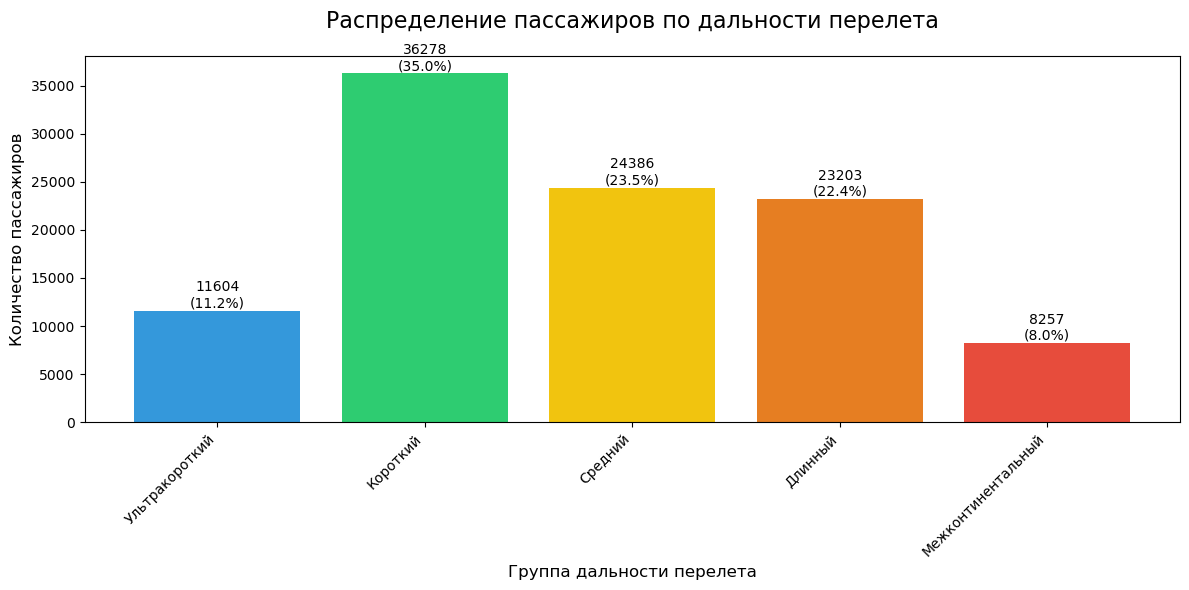

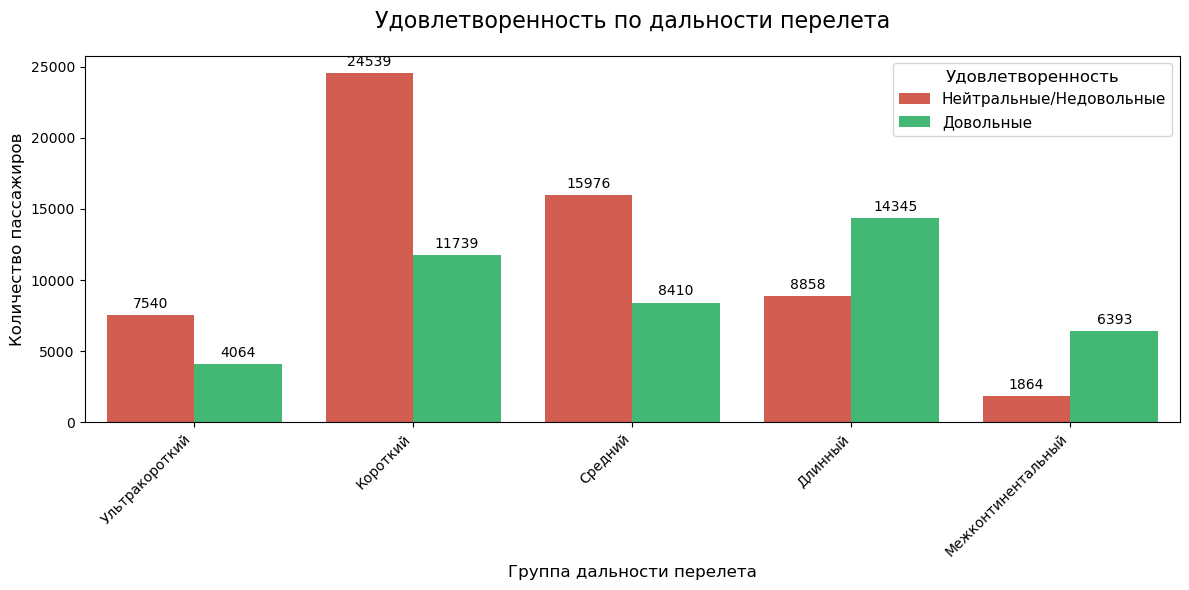

In [23]:
plt.figure(figsize=(12, 6))

distance_counts = df['Flight_Distance_Group'].value_counts().sort_index()
colors = ['#3498db', '#2ecc71', '#f1c40f', '#e67e22', '#e74c3c']
bars = plt.bar(distance_counts.index, distance_counts.values, color=colors)

plt.title('Распределение пассажиров по дальности перелета', fontsize=16, pad=20)
plt.xlabel('Группа дальности перелета', fontsize=12)
plt.ylabel('Количество пассажиров', fontsize=12)
plt.xticks(rotation=45, ha='right')

for bar, count, label in zip(bars, distance_counts.values, labels):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 5,
             f'{count}\n({count/len(df)*100:.1f}%)',
             ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))

ax = sns.countplot(data=df, x='Flight_Distance_Group', hue='satisfaction',
                   order=labels,
                   palette={'neutral or dissatisfied': '#e74c3c',
                            'satisfied': '#2ecc71'})

plt.title('Удовлетворенность по дальности перелета', fontsize=16, pad=20)
plt.xlabel('Группа дальности перелета', fontsize=12)
plt.ylabel('Количество пассажиров', fontsize=12)
plt.xticks(rotation=45, ha='right')

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3)

handles, labels_legend = ax.get_legend_handles_labels()
ax.legend(handles, ['Нейтральные/Недовольные', 'Довольные'],
          title='Удовлетворенность',
          title_fontsize=12,
          fontsize=11)

plt.tight_layout()
plt.show()

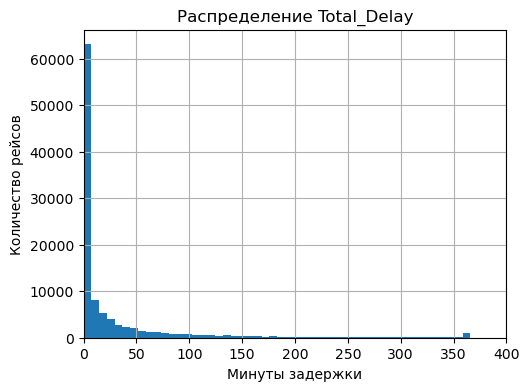

In [24]:
df['Total_Delay'] = df['Departure Delay in Minutes'] + df['Arrival Delay in Minutes']

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
df['Total_Delay'].hist(bins=50)
plt.title('Распределение Total_Delay')
plt.xlabel('Минуты задержки')
plt.ylabel('Количество рейсов')
plt.xlim(0, 400)

plt.show()

In [25]:
service_columns = [
    'Inflight wifi service',
    'Departure/Arrival time convenient',
    'Ease of Online booking',
    'Gate location',
    'Food and drink',
    'Online boarding',
    'Seat comfort',
    'Inflight entertainment',
    'On-board service',
    'Leg room service',
    'Baggage handling',
    'Checkin service',
    'Inflight service',
    'Cleanliness'
]
df['Overall_Service_Score'] = df[service_columns].mean(axis=1)

Статистики Overall_Service_Score:
Минимум: 1.07
Максимум: 5.00
Среднее: 3.24
Медиана: 3.29
Стандартное отклонение: 0.66


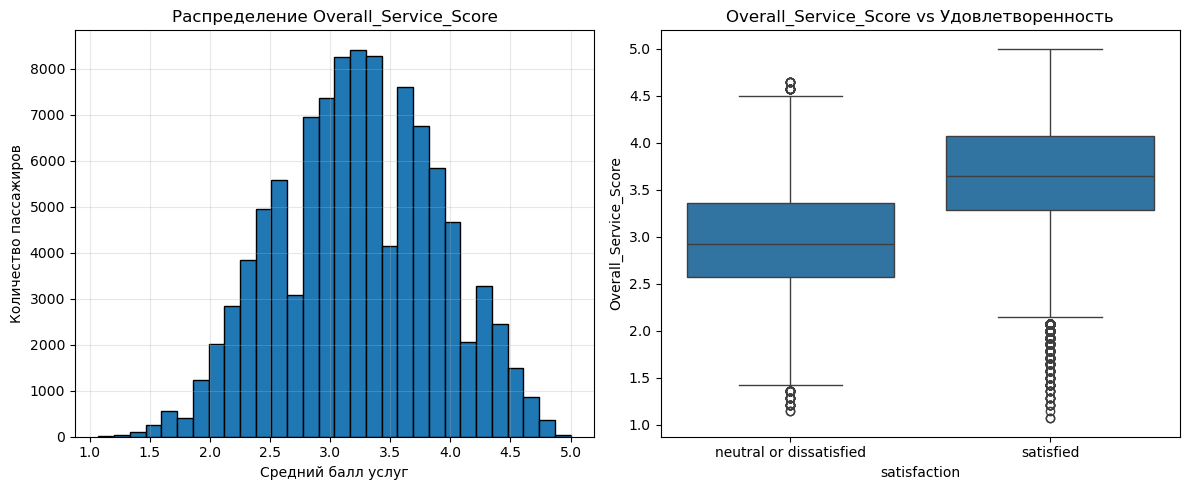

In [26]:
print("Статистики Overall_Service_Score:")
print(f"Минимум: {df['Overall_Service_Score'].min():.2f}")
print(f"Максимум: {df['Overall_Service_Score'].max():.2f}")
print(f"Среднее: {df['Overall_Service_Score'].mean():.2f}")
print(f"Медиана: {df['Overall_Service_Score'].median():.2f}")
print(f"Стандартное отклонение: {df['Overall_Service_Score'].std():.2f}")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
df['Overall_Service_Score'].hist(bins=30, edgecolor='black')
plt.title('Распределение Overall_Service_Score')
plt.xlabel('Средний балл услуг')
plt.ylabel('Количество пассажиров')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='satisfaction', y='Overall_Service_Score')
plt.title('Overall_Service_Score vs Удовлетворенность')

plt.tight_layout()
plt.show()

Общее качество данных - среднее, так как, с одной стороны, данные структурированы, большая часть данных заполнена, достаточно много признаков, с другой стороны - есть и слабые стороны. В данных есть пропуски, что негативно сказывается на анализе данных. Пропуски приходилось заменять на медианные значения и на моду.

В ходе анализа удалось выявить некоторые взаимосвязи. Так, была выявлена связь между степенью удовлетворённостью полётом и теми пассажирами. у которых тип путешествия был Business Travel. Среди таких пассажиров было больше людей, которым понравился полёт за счёт того, что большая часть из них летала бизнес-классом. В то время как люди летевшие эконом классом или эконом-плюс оставляли нейтральную и негативную оценку. Соответственно, можно сделать вывод, что на степень удовлетворённости полётом также влияет и класс, которым летели пассажиры.
Удовлетворённость сильно коррелирует с классом перелёта: пассажиры бизнес-класса получают более высокий уровень сервиса, что отражается на их оценке. В эконом-классе и Eco Plus сервис, по-видимому, не соответствует ожиданиям большинства пассажиров. Ни пол, ни возраст не является значимым фактором в различиях удовлетворённости — важнее класс обслуживания.

Стоит отметить, что есть зависимость между длительностью полёта и тем, понравился полёт или нет. Чем больше расстояние, тем меньше негативных и нейтральных отзывов.

 Кроме того, есть взаимосвязь между оценкой пассажирами услуг, предоставляемых во время полёта, и понравился полёт или нет. Средняя оценка услуг - 3,24, причём если средняя оценка ниже этого значения, то пассажиру, скорее всего не понравился полёт.

На основе тепловой карты корреляций выявлены взаимосвязи между отдельными аспектами обслуживания:
Задержки рейсов (Departure Delay in Minutes и Arrival Delay in Minutes) демонстрируют практически полную линейную зависимость (корреляция 0,96). Это подтверждает, что задержка вылета почти неизбежно ведёт к задержке прилёта, что необходимо учитывать в управлении расписаниями.
Обнаружена устойчивая связь между оценкой комфорта сидений и качества развлечений на борту (корреляция 0,61). Это свидетельствует о том, что пассажиры склонны оценивать эти два аспекта в комплексе: комфортная посадка усиливает впечатление от развлечений.
Питание на борту и развлечения также тесно связаны (корреляция 0,62), что указывает на важность комплексного подхода к организации досуга и питания во время полёта.
Обработка багажа и обслуживание на борту имеют заметную положительную связь (корреляция 0,63). Это подчёркивает, что негативный опыт на земле (например, проблемы с багажом) может повлиять на общую оценку полёта, даже если обслуживание в воздухе было на высоком уровне.
Простота онлайн-бронирования билетов и качество wifi также сильно коррелируют (0,72), что показывает схожесть ожиданий от цифровых сервисов у пассажиров. Улучшение одного из этих критериев может положительно сказаться на другом.

Оценка услуг, оказываемых в процессе полёта, в целом носит позитивный характер — по большинству показателей количество положительных отзывов превышает количество нейтральных и негативных. Исключение составляют два параметра: удобство расположения выходов (gate location) и удобство времени вылета и прилёта, где ситуация обратная: преобладают критические и нейтральные оценки.

In [27]:
categorical_cols = ['Gender', 'Customer Type', 'Type of Travel', 'Class']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

In [28]:
if 'Date' in df.columns:
    try:
        df['Date'] = pd.to_datetime(df['Date'])
        df['DayOfWeek'] = df['Date'].dt.dayofweek
        df['IsWeekend'] = df['DayOfWeek'] >= 5
        df['DayOfMonth'] = df['Date'].dt.day

        print("Распределение по дням недели:")
        print(df['DayOfWeek'].value_counts().sort_index())

        print("\nРаспределение по выходным/рабочим дням:")
        print(df['IsWeekend'].value_counts())

        df.drop('Date', axis=1, inplace=True)

    except Exception as e:
        print(f"Не удалось обработать дату: {e}")
        df.drop('Date', axis=1, inplace=True)

Распределение по дням недели:
DayOfWeek
0    16445
1    16316
2    13085
3    12817
4    12882
5    15986
6    16197
Name: count, dtype: int64

Распределение по выходным/рабочим дням:
IsWeekend
False    71545
True     32183
Name: count, dtype: int64


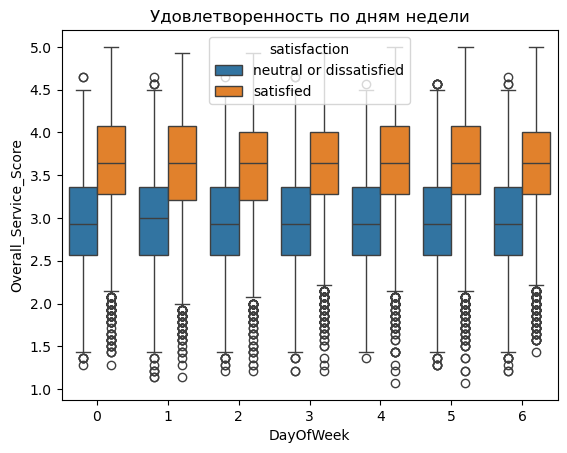

Type of Travel,Business travel,Personal Travel
IsWeekend,,
False,49397,22148
True,22136,10047


In [29]:
sns.boxplot(data=df, x='DayOfWeek', y='Overall_Service_Score', hue='satisfaction')
plt.title('Удовлетворенность по дням недели')
plt.show()

pd.crosstab(df['IsWeekend'], df['Type of Travel'])

In [30]:
df['satisfaction_numeric'] = df['satisfaction'].map({
    'satisfied': 1,
    'neutral or dissatisfied': 0
})
df['Had_Delay'] = (df['Total_Delay'] > 0).astype(int)
wifi_ok = df['Inflight wifi service'] >= 3
entertainment_ok = df['Inflight entertainment'] >= 3
df['Good_Entertainment'] = (wifi_ok & entertainment_ok).astype(int)
df['High_Service_Score'] = (df['Overall_Service_Score'] >= 4).astype(int)
df['Is_Male'] = (df['Gender'] == 'Male').astype(int)
df['Is_Loyal'] = (df['Customer Type'] == 'Loyal Customer').astype(int)
df['Is_Business_Travel'] = (df['Type of Travel'] == 'Business travel').astype(int)

df['Service_Level'] = pd.cut(df['Overall_Service_Score'], 
                             bins=[0, 2, 3.5, 5], 
                             labels=['Low', 'Medium', 'High'])

df['Delay_Group'] = pd.cut(df['Total_Delay'], 
                           bins=[-1, 0, 30, 120, 1000], 
                           labels=['No Delay', 'Short', 'Medium', 'Long'])

df['Travel_Class_Combo'] = df['Type of Travel'] + '_' + df['Class']

In [31]:
df.to_csv('data_summary.csv', index=False, encoding='utf-8-sig')

In [32]:
df = df.drop(['Gender', 'Customer Type'], axis=1)

In [33]:
category_features = [
    'Class',
    'Age_Group',
    'Flight_Distance_Group',
    'Service_Level',
    'Delay_Group',
    'Travel_Class_Combo',
    'Type of Travel'
]

In [34]:
df_one_hot_enc = pd.get_dummies(df, columns=category_features, drop_first=True)

In [35]:
X = df_one_hot_enc.drop(['satisfaction', 'satisfaction_numeric'], axis=1)

columns_to_drop = [
    'id',
    'Total_Delay',
    'Inflight wifi service',
    'Inflight entertainment',
    'Overall_Service_Score',
    'Departure Delay in Minutes',
    'Arrival Delay in Minutes'
]
X = X.drop(columns_to_drop, axis=1, errors='ignore')

y = df['satisfaction_numeric']

In [36]:
X.head()

,Age,Flight Distance,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,On-board service,Leg room service,...,Service_Level_High,Delay_Group_Short,Delay_Group_Medium,Delay_Group_Long,Travel_Class_Combo_Business travel_Eco Plus,Travel_Class_Combo_Business travel_Econom,Travel_Class_Combo_Personal Travel_Business,Travel_Class_Combo_Personal Travel_Eco Plus,Travel_Class_Combo_Personal Travel_Econom,Type of Travel_Personal Travel
0,13,460,4,3.0,1,5,3,5,4,3.0,...,True,False,True,False,False,False,False,True,False,True
1,25,235,2,3.0,3,1,3,1,1,5.0,...,False,True,False,False,False,False,False,False,False,False
2,26,1142,2,2.0,2,5,5,5,4,3.0,...,True,False,False,False,False,False,False,False,False,False
3,25,562,5,5.0,5,2,2,2,2,5.0,...,False,True,False,False,False,False,False,False,False,False
4,61,214,3,3.0,3,4,5,5,3,4.0,...,False,False,False,False,False,False,False,False,False,False


In [37]:
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [48]:
smote = SMOTE(
    sampling_strategy='auto',
    random_state=42
)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

In [39]:
print("До сэмплирования:")
print(y_train.value_counts())
print("\nПосле сэмплирования:")
print(y_train_resampled.value_counts())

До сэмплирования:
satisfaction_numeric
0    47021
1    35961
Name: count, dtype: int64

После сэмплирования:
satisfaction_numeric
0    47021
1    47021
Name: count, dtype: int64


In [40]:
def predict_results(model, X_train, X_valid, y_train, y_valid):

    model.fit(X_train, y_train)

    y_pred = model.predict(X_valid)

    accuracy = accuracy_score(y_valid, y_pred)
    precision = precision_score(y_valid, y_pred)
    recall = recall_score(y_valid, y_pred)
    f1 = f1_score(y_valid, y_pred)

    print(f"Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1-score: {f1:.4f}")

    ConfusionMatrixDisplay.from_estimator(model, X_valid, y_valid)
    plt.show()

### Логистическая регрессия

In [41]:
from sklearn.linear_model import LogisticRegression

In [45]:
from sklearn.model_selection import cross_val_score

In [55]:
lr_model = LogisticRegression(C=1.0, penalty='l2', solver='lbfgs', max_iter=5000, random_state=42, tol=1e-4, verbose=0)

In [50]:
print(y_valid.value_counts())

satisfaction_numeric
0    11756
1     8990
Name: count, dtype: int64


C:\Users\pdroz\AppData\Local\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy: 0.8729, Precision: 0.8726, Recall: 0.8275, F1-score: 0.8494


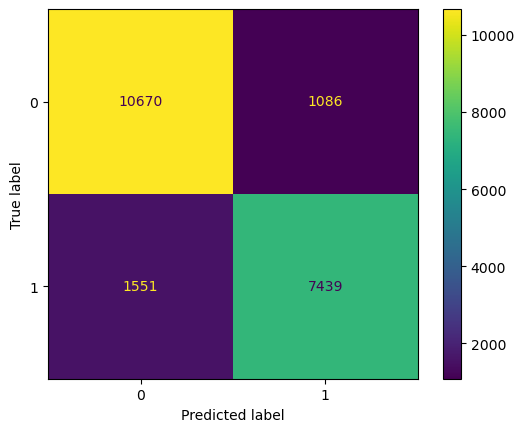

In [56]:
predict_results(lr_model, X_train, X_valid, y_train, y_valid)

C:\Users\pdroz\AppData\Local\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy: 0.8655, Precision: 0.8508, Recall: 0.8364, F1-score: 0.8435


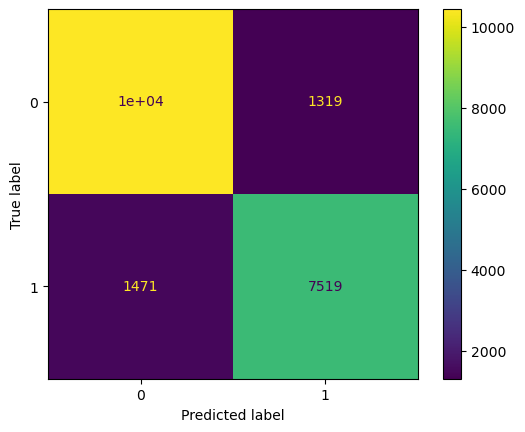

In [57]:
predict_results(lr_model, X_train_resampled, X_valid, y_train_resampled, y_valid)

In [4]:
from sklearn.model_selection import GridSearchCV

In [63]:
from sklearn.preprocessing import StandardScaler

In [64]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_valid)

In [65]:
param_grid = {
'C': [0.001, 0.01, 0.1, 1, 10, 100],
'penalty': ['l1', 'l2'],
'solver': ['liblinear', 'saga']
}

In [66]:
grid_search = GridSearchCV(
estimator=LogisticRegression(random_state=42),
param_grid=param_grid,
cv=5,
scoring='roc_auc',
n_jobs=-1
)

In [67]:
grid_search.fit(X_train_scaled, y_train)

GridSearchCV(cv=5, estimator=LogisticRegression(random_state=42), n_jobs=-1,
             param_grid={'C': [0.001, 0.01, 0.1, 1, 10, 100],
                         'penalty': ['l1', 'l2'],
                         'solver': ['liblinear', 'saga']},
             scoring='roc_auc')

In [68]:
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_train_scaled)

Best parameters: {'C': 10, 'penalty': 'l1', 'solver': 'liblinear'}
Best cross-validation score: 0.9244


In [69]:
best_params = grid_search.best_params_

In [70]:
final_model = LogisticRegression(
    C=best_params['C'],
    penalty=best_params['penalty'],
    solver=best_params['solver'],
    random_state=42,
    max_iter=1000
)

In [71]:
final_model.fit(X_train_scaled, y_train)

LogisticRegression(C=10, max_iter=1000, penalty='l1', random_state=42,
                   solver='liblinear')

Accuracy: 0.8730, Precision: 0.8723, Recall: 0.8283, F1-score: 0.8497


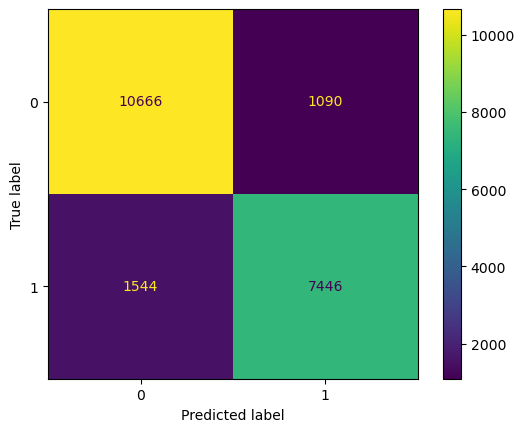

In [72]:
predict_results(final_model, X_train, X_valid, y_train, y_valid)

Accuracy: 0.8660, Precision: 0.8517, Recall: 0.8364, F1-score: 0.8440


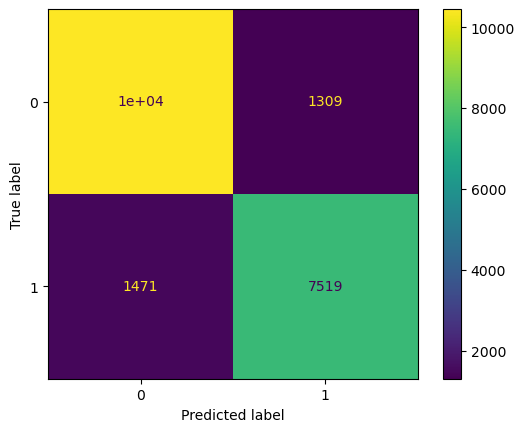

In [73]:
predict_results(final_model, X_train_resampled, X_valid, y_train_resampled, y_valid)

In [74]:
accuracy = cross_val_score(final_model, X, y, cv=5, scoring='accuracy').mean()
precision = cross_val_score(final_model, X, y, cv=5, scoring='precision').mean()
recall = cross_val_score(final_model, X, y, cv=5, scoring='recall').mean()
f1 = cross_val_score(final_model, X, y, cv=5, scoring='f1').mean()

print(f"Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1-score: {f1:.4f}")

Accuracy: 0.8732, Precision: 0.8773, Recall: 0.8224, F1-score: 0.8489


### KNN

In [8]:
from sklearn.neighbors import KNeighborsClassifier

In [76]:
knn_model = KNeighborsClassifier(
    n_neighbors=5,
    metric="euclidean",
    weights="uniform",
)

Accuracy: 0.7453, Precision: 0.7220, Recall: 0.6704, F1-score: 0.6952


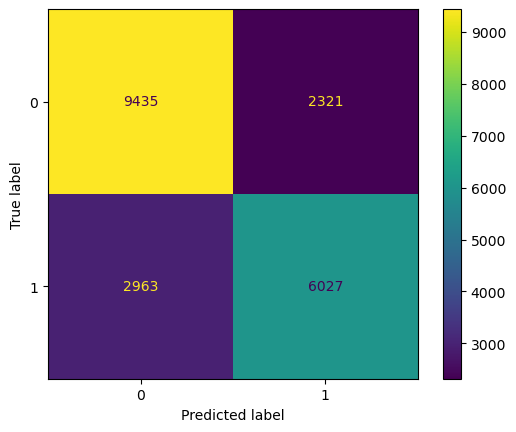

In [77]:
predict_results(knn_model, X_train, X_valid, y_train, y_valid)

Accuracy: 0.7272, Precision: 0.6692, Recall: 0.7325, F1-score: 0.6994


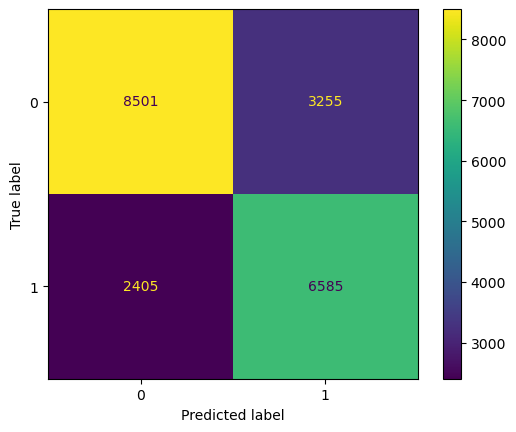

In [78]:
predict_results(knn_model, X_train_resampled, X_valid, y_train_resampled, y_valid)

In [11]:
param_grid = {
'n_neighbors': list(range(3, 10)),
'weights': ['uniform', 'distance'],
'metric': ['euclidean', 'manhattan', 'minkowski'],
'p': [1, 2, 3]
}

In [9]:
knn = KNeighborsClassifier()

In [12]:
grid_search = GridSearchCV(
knn, param_grid, cv=5, 
scoring='accuracy', n_jobs=-1, verbose=1
)

In [ ]:
grid_search.fit(X_train, y_train)

In [ ]:
print(f"Лучшие параметры: {grid_search.best_params_}")
print(f"Лучшая точность при кросс-валидации: {grid_search.best_score_:.4f}")

best_knn = grid_search.best_estimator_

In [ ]:
predict_results(best_knn, X_train, X_valid, y_train, y_valid)

In [ ]:
predict_results(best_knn, X_train_resampled, X_valid, y_train_resampled, y_valid)

In [ ]:
accuracy = cross_val_score(best_knn, X, y, cv=5, scoring='accuracy').mean()
precision = cross_val_score(best_knn, X, y, cv=5, scoring='precision').mean()
recall = cross_val_score(best_knn, X, y, cv=5, scoring='recall').mean()
f1 = cross_val_score(best_knn, X, y, cv=5, scoring='f1').mean()

print(f"Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1-score: {f1:.4f}")

### Дерево решений

In [84]:
from sklearn.tree import DecisionTreeClassifier

In [85]:
dt_model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=5,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features=None,
    min_impurity_decrease=0.0,
    random_state=42
)

Accuracy: 0.8797, Precision: 0.8315, Recall: 0.9060, F1-score: 0.8671


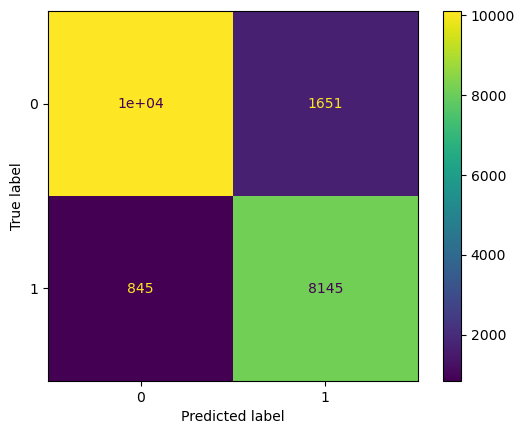

In [86]:
predict_results(dt_model, X_train, X_valid, y_train, y_valid)

Accuracy: 0.8923, Precision: 0.8814, Recall: 0.8682, F1-score: 0.8748


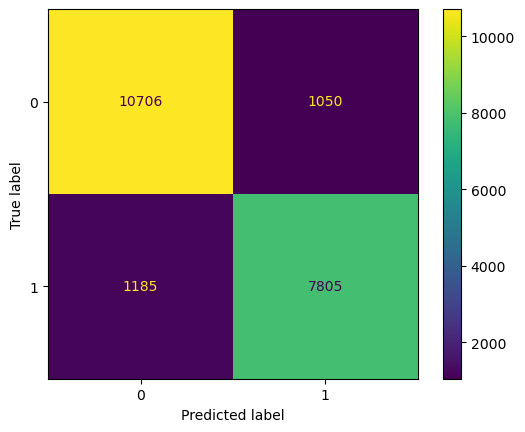

In [87]:
predict_results(dt_model, X_train_resampled, X_valid, y_train_resampled, y_valid)

In [88]:
accuracy = cross_val_score(dt_model, X, y, cv=5, scoring='accuracy').mean()
precision = cross_val_score(dt_model, X, y, cv=5, scoring='precision').mean()
recall = cross_val_score(dt_model, X, y, cv=5, scoring='recall').mean()
f1 = cross_val_score(dt_model, X, y, cv=5, scoring='f1').mean()

print(f"Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1-score: {f1:.4f}")

Accuracy: 0.8788, Precision: 0.8326, Recall: 0.9016, F1-score: 0.8657


In [89]:
param_grid = {
'max_depth': [3, 4, 5, 6, 7],
'min_samples_split': [2, 5, 10],
'min_samples_leaf': [1, 2, 4],
'criterion': ['gini', 'entropy']
}

In [90]:
grid_search = GridSearchCV(
DecisionTreeClassifier(random_state=42),
param_grid,
cv=5,
scoring='accuracy',
n_jobs=-1
)

In [91]:
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [3, 4, 5, 6, 7],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10]},
             scoring='accuracy')

In [92]:
print("Лучшие параметры:", grid_search.best_params_)
print("Лучшая точность:", grid_search.best_score_)

Лучшие параметры: {'criterion': 'entropy', 'max_depth': 7, 'min_samples_leaf': 4, 'min_samples_split': 2}
Лучшая точность: 0.9126799058386543


In [93]:
best_tree = grid_search.best_estimator_

In [94]:
accuracy = cross_val_score(best_tree, X, y, cv=5, scoring='accuracy').mean()
precision = cross_val_score(best_tree, X, y, cv=5, scoring='precision').mean()
recall = cross_val_score(best_tree, X, y, cv=5, scoring='recall').mean()
f1 = cross_val_score(best_tree, X, y, cv=5, scoring='f1').mean()

print(f"Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1-score: {f1:.4f}")

Accuracy: 0.9132, Precision: 0.8965, Recall: 0.9042, F1-score: 0.9003


Accuracy: 0.9141, Precision: 0.8920, Recall: 0.9122, F1-score: 0.9020


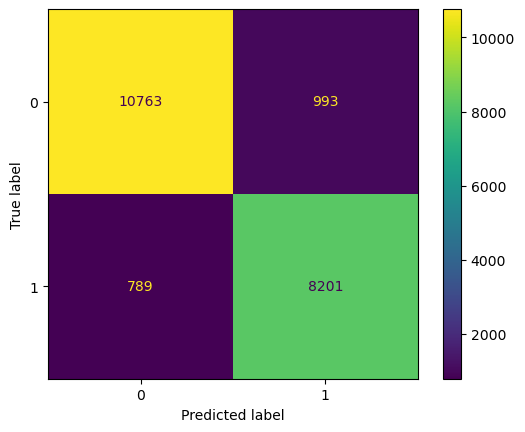

In [95]:
predict_results(best_tree, X_train, X_valid, y_train, y_valid)

Accuracy: 0.9071, Precision: 0.8934, Recall: 0.8920, F1-score: 0.8927


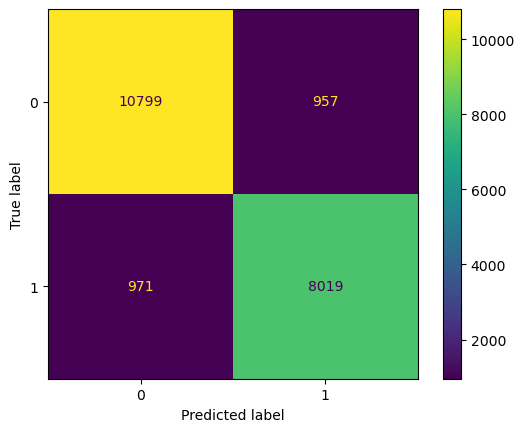

In [96]:
predict_results(best_tree, X_train_resampled, X_valid, y_train_resampled, y_valid)

### Оценка важности

In [97]:
feature_importances = best_tree.feature_importances_

feature_importance_df = pd.DataFrame({
    "Признак": X.columns,
    "Важность": feature_importances
})

feature_importance_df = feature_importance_df.sort_values(by="Важность", ascending=False)

In [98]:
feature_importance_df

,Признак,Важность
6,Online boarding,0.399209
22,Is_Business_Travel,0.179104
3,Ease of Online booking,0.131849
33,Service_Level_High,0.086025
21,Is_Loyal,0.064531
10,Baggage handling,0.049175
7,Seat comfort,0.017487
8,On-board service,0.014843
13,Cleanliness,0.010482
32,Service_Level_Medium,0.008562


Согласно полученным данным лучшей моделью оказалось дерево решений с показателем F1 - 0.9020. Причём эта модель показала лучшее качество по метрике F1 после использования следующих параметров: criterion='entropy', max_depth=7, min_samples_leaf=4,random_state=42 на несэмплированных данных.

На втором месте оказалось модель, построенная на логистической регрессии с метрикой F1-score: 0.8497, обученная также не на сэмплированных данных, со следующими параметрами: C=10, max_iter=1000, penalty='l1', random_state=42, solver='liblinear'.

И на последнем месте оказалась KNN. Для неё параметры не удалось подобрать из-за технических неполадок. По метрике F1 получилось 0.6994 в лучшем случае при параметрах:    n_neighbors=5, metric="euclidean", weights="uniform".

Таким образом, дерево решений оказалось самым подходящим методом построения предиктивной модели

Стоит отметить и полученные результаты оценки важности признаков. В топ-5 вошли: Online boarding	0.399209, Is_Business_Travel	0.179104, Ease of Online booking	0.131849, Service_Level_High	0.086025, Is_Loyal	0.064531. 3 из этих признака, а именно Is_Business_Travel, Service_Level_High, Is_Loyal, были добавлены в ходе подготовки данных. Самым значимым признаком стал Online boarding, что подтверждает факт: люди всё чаще оценивают услуги с точки зрения удобства цифровых сервисов.